# SageBat — chirp autoencoder (single clip)

Bat echolocation call -> encoder -> small latent vector -> decoder -> reconstructed call.

## What this pipeline does and why each piece is there

**Why detect first.** Calls are rare — a few tens of milliseconds of bat in a one-second
recording. Feed an autoencoder every frame and ~97% of its training signal is empty
background, so it minimizes error by learning to reproduce noise. Every training row here is
a patch centred on a detected call.

**Why 1.33 ms frames.** Chirps last 1–2 ms. The earlier pipeline used 40 ms Welch-averaged
frames, which diluted each call ~20x into the background — not filtered out, averaged away.

**Why 45–100 kHz.** The loud persistent chorus in this recording cuts off around 45 kHz and
sits 20+ dB above the calls. Starting above it removes the easy, loud signal the model would
otherwise spend all its capacity on.

**Why the 90th percentile for detection.** A chirp occupies maybe 20 of 74 bins at any
instant, so averaging across bins dilutes it against 54 bins of noise. The percentile asks
"how loud is the loud part of this frame," which sharpens contrast from ~3–9 dB to ~9–21 dB.

**Why leave-one-call-out.** All the detected clips capture the same calls, so there is one
file's worth of data. With roughly ten calls, LOO is the only honest split available.

## What this can and cannot show

It can establish that the detection and representation work, and that a small latent vector
preserves sweep structure. It **cannot** support a claim that N dimensions describe bat calls
in general — that needs the detector run across the full recording, over many bouts and
many individuals. Treat every number below as illustrative.

## 1. Configuration

In [3]:
import glob
import os

import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.decomposition import PCA

# ---- data --------------------------------------------------------------
CLIP_DIR = "/home/jgersey/SageBat/detected_clips"
CLIP_INDEX = 0                   # which clip to use

# ---- spectrogram (sized for millisecond transients) --------------------
N_FFT = 512                      # ~1.33 ms at 384 kHz
HOP = 128                        # ~0.33 ms
F_LO, F_HI = 45_000, 100_000     # above the background chorus

# ---- detection ---------------------------------------------------------
PCTL = 90                        # per-frame statistic across bins
THRESH_DB = 5                    # above the clip median
MIN_GAP = 3                      # frames; closer hits merge into one call
PATCH_T = 24                     # frames per patch (~8 ms)

# ---- augmentation (training folds only) --------------------------------
SHIFTS = [-4, -2, 0, 2, 4]       # time shifts, frames
GAINS_DB = [-2, 0, 2]            # amplitude jitter

# ---- model / training --------------------------------------------------
LATENT = 4
BATCH_SIZE = 64
EPOCHS = 300
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 40
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("device:", device)

WINDOW = np.hanning(N_FFT)
criterion = nn.MSELoss()

device: cuda


In [4]:
clips = sorted(glob.glob(os.path.join(CLIP_DIR, "*.wav")))
if not clips:
    raise SystemExit("no clips found - check CLIP_DIR")

CLIP = clips[CLIP_INDEX]
info = sf.info(CLIP)
SR = info.samplerate

print(f"{len(clips)} clips available; using {os.path.basename(CLIP)}")
print(f"{info.frames} samples, {SR} Hz, {info.duration:.3f} s")
print(f"frame {N_FFT/SR*1000:.2f} ms   hop {HOP/SR*1000:.2f} ms")
print(f"a 2 ms chirp spans ~{2.0/(HOP/SR*1000):.0f} frames")
print(f"patch = {PATCH_T} frames = {PATCH_T*HOP/SR*1000:.1f} ms")

1 clips available; using 20260414_100939_det0004.wav
384000 samples, 384000 Hz, 1.000 s
frame 1.33 ms   hop 0.33 ms
a 2 ms chirp spans ~6 frames
patch = 24 frames = 8.0 ms


## 2. Spectrogram

Plain STFT, band-limited, in dB. No Welch averaging and no band pooling — both are right for
characterising a stationary background and wrong for transients, where the point is to keep
the instantaneous structure.

In [5]:
def clip_spectrogram(path, f_lo=F_LO, f_hi=F_HI, n_fft=N_FFT, hop=HOP):
    x, sr = sf.read(path, dtype="float64", always_2d=True)
    x = np.ascontiguousarray(x[:, 0])
    freqs = np.fft.rfftfreq(n_fft, d=1 / sr)
    keep = np.where((freqs >= f_lo) & (freqs <= f_hi))[0]
    n = 1 + (len(x) - n_fft) // hop
    frames = np.lib.stride_tricks.as_strided(
        x, shape=(n, n_fft), strides=(x.strides[0] * hop, x.strides[0])
    )
    p = np.abs(np.fft.rfft(frames * WINDOW, axis=1)) ** 2
    db = 10 * np.log10(np.maximum(p[:, keep], 1e-20))
    return db, freqs[keep], sr


db, band_freqs, SR = clip_spectrogram(CLIP)
N_BINS = len(band_freqs)
t_axis = np.arange(db.shape[0]) * HOP / SR

print(f"spectrogram {db.shape} (frames x bins)")
print(f"bands: {N_BINS}  {band_freqs[0]/1000:.1f}-{band_freqs[-1]/1000:.1f} kHz "
      f"({band_freqs[1]-band_freqs[0]:.0f} Hz each)")

spectrogram (2997, 74) (frames x bins)
bands: 74  45.0-99.8 kHz (750 Hz each)


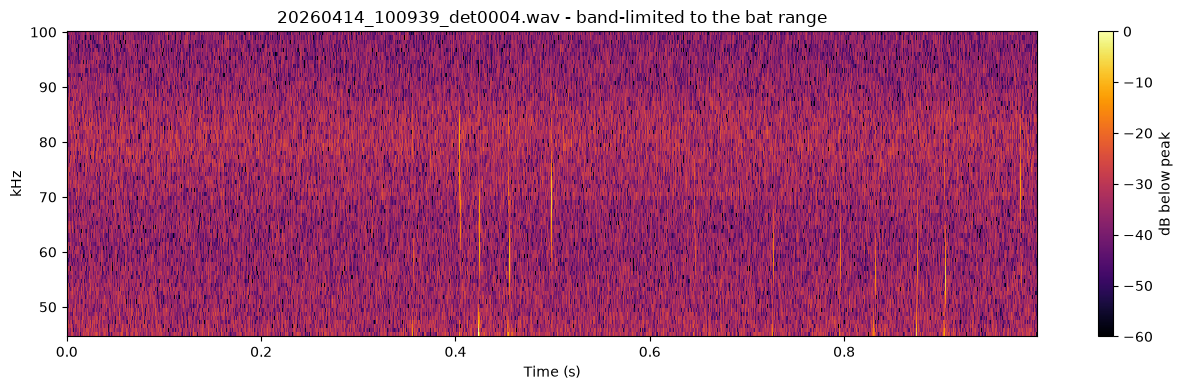

In [6]:
plt.figure(figsize=(13, 4))
plt.pcolormesh(t_axis, band_freqs / 1000, (db - db.max()).T,
               shading="auto", cmap="inferno", vmin=-60, vmax=0)
plt.xlabel("Time (s)"); plt.ylabel("kHz")
plt.title(f"{os.path.basename(CLIP)} - band-limited to the bat range")
plt.colorbar(label="dB below peak")
plt.tight_layout(); plt.show()

## 3. Detect the calls

Per-frame 90th-percentile energy across bins, thresholded against the clip's own median. Runs
of adjacent frames collapse into one detection, centred on the loudest frame.

Read the lower panel before continuing: every call should cross the line, and the background
between calls should stay well under it.

In [7]:
def detect(db, pctl=PCTL, thresh_db=THRESH_DB, min_gap=MIN_GAP):
    energy = np.percentile(db, pctl, axis=1)
    base = np.median(energy)
    hits = np.where(energy > base + thresh_db)[0]
    if len(hits) == 0:
        return np.array([], dtype=int), energy, base
    groups = np.split(hits, np.where(np.diff(hits) > min_gap)[0] + 1)
    centres = np.array([int(g[np.argmax(energy[g])]) for g in groups])
    return centres, energy, base


centres, energy, base = detect(db)
print(f"{len(centres)} calls detected")
print("times (s):", np.round(centres * HOP / SR, 3).tolist())
print(f"background floor {base:.1f} dB, "
      f"jitter +/- {np.std(energy[energy < base + 2]):.2f} dB")
print(f"threshold at {base + THRESH_DB:.1f} dB")

12 calls detected
times (s): [0.356, 0.405, 0.425, 0.455, 0.499, 0.647, 0.727, 0.796, 0.832, 0.876, 0.904, 0.982]
background floor -35.1 dB, jitter +/- 0.88 dB
threshold at -30.1 dB


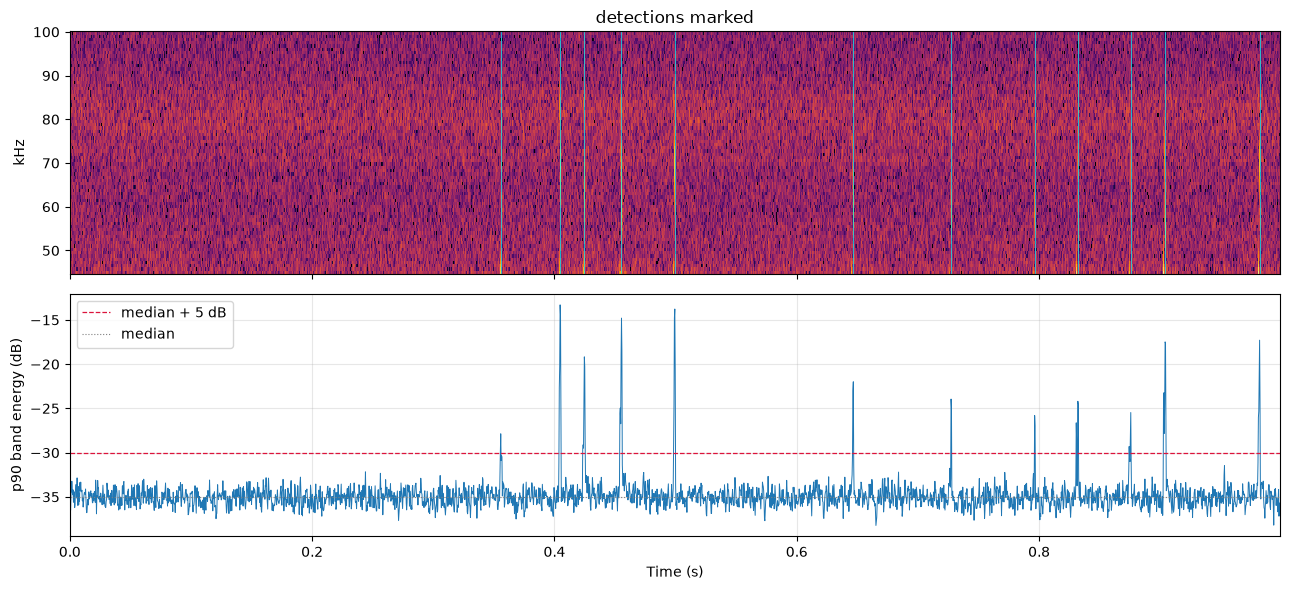

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax[0].pcolormesh(t_axis, band_freqs / 1000, (db - db.max()).T,
                 shading="auto", cmap="inferno", vmin=-60, vmax=0)
for c in centres:
    ax[0].axvline(c * HOP / SR, color="cyan", lw=0.6, alpha=0.8)
ax[0].set_ylabel("kHz"); ax[0].set_title("detections marked")

ax[1].plot(t_axis, energy, lw=0.7)
ax[1].axhline(base + THRESH_DB, ls="--", c="crimson", lw=0.9,
              label=f"median + {THRESH_DB} dB")
ax[1].axhline(base, ls=":", c="gray", lw=0.8, label="median")
ax[1].set_xlabel("Time (s)"); ax[1].set_ylabel(f"p{PCTL} band energy (dB)")
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [9]:
# How sensitive is the count to the threshold?
print("threshold sweep:")
for th in [3, 4, 5, 6, 8, 10]:
    c, _, _ = detect(db, thresh_db=th)
    print(f"  median + {th:2d} dB -> {len(c):3d} calls")
print()
print("Pick a value on the plateau, not on a steep part of this curve.")

threshold sweep:
  median +  3 dB ->  13 calls
  median +  4 dB ->  12 calls
  median +  5 dB ->  12 calls
  median +  6 dB ->  12 calls
  median +  8 dB ->  12 calls
  median + 10 dB ->   9 calls

Pick a value on the plateau, not on a steep part of this curve.


## 4. Extract patches

Each detection becomes a `PATCH_T x N_BINS` window centred on the call.

Background patches are cut from quiet stretches of the same clip as a **control**. They are
the key diagnostic later: if the model reconstructs background as well as it reconstructs
calls, it has learned this clip's noise floor rather than call structure.

In [10]:
def cut(c, shift=0):
    lo, hi = c + shift - PATCH_T // 2, c + shift + PATCH_T // 2
    if lo < 0 or hi > db.shape[0]:
        return None
    return db[lo:hi]


usable = [i for i, c in enumerate(centres) if cut(c) is not None]
call_centres = centres[usable]
calls = np.stack([cut(c) for c in call_centres]).astype(np.float32)
call_t = call_centres * HOP / SR
N_CALLS = len(calls)

# background controls, away from any detection
quiet = np.ones(db.shape[0], bool)
for c in centres:
    quiet[max(0, c - PATCH_T):c + PATCH_T] = False
valid = np.where(quiet)[0]
valid = valid[(valid >= PATCH_T // 2) & (valid < db.shape[0] - PATCH_T // 2)]
n_bg = min(N_CALLS * 3, len(valid))
bg_pick = np.random.default_rng(RANDOM_SEED).choice(valid, size=n_bg, replace=False)
BG = np.stack([db[c - PATCH_T // 2:c + PATCH_T // 2] for c in bg_pick]).astype(np.float32)

print(f"calls      : {calls.shape}")
print(f"background : {BG.shape}")
print(f"input dim  : {PATCH_T * N_BINS}")
print(f"training examples per fold: {N_CALLS - 1} calls "
      f"x {len(SHIFTS)} shifts x {len(GAINS_DB)} gains = "
      f"{(N_CALLS - 1) * len(SHIFTS) * len(GAINS_DB)}")

if N_CALLS < 20:
    print()
    print(f"NOTE: {N_CALLS} calls from one bout. This demonstrates the pipeline;")
    print("      it does not establish generalization to other bats or nights.")

calls      : (12, 24, 74)
background : (36, 24, 74)
input dim  : 1776
training examples per fold: 11 calls x 5 shifts x 3 gains = 165

NOTE: 12 calls from one bout. This demonstrates the pipeline;
      it does not establish generalization to other bats or nights.


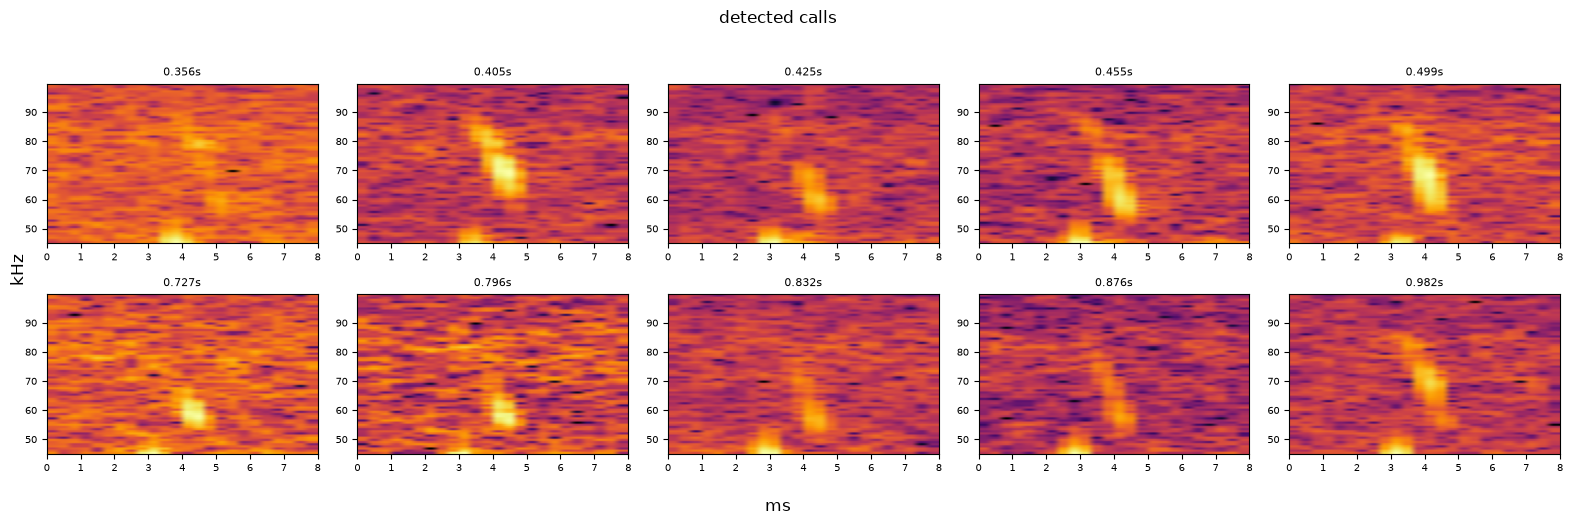

In [11]:
ext = [0, PATCH_T * HOP / SR * 1000, band_freqs[0] / 1000, band_freqs[-1] / 1000]
n_show = min(10, N_CALLS)
idx = np.linspace(0, N_CALLS - 1, n_show).astype(int)

fig, axes = plt.subplots(2, 5, figsize=(16, 5))
for a, i in zip(axes.ravel(), idx):
    a.imshow(calls[i].T, aspect="auto", origin="lower", cmap="inferno", extent=ext)
    a.set_title(f"{call_t[i]:.3f}s", fontsize=8)
    a.tick_params(labelsize=7)
for a in axes.ravel()[n_show:]:
    a.axis("off")
fig.supxlabel("ms"); fig.supylabel("kHz")
plt.suptitle("detected calls", y=1.02)
plt.tight_layout(); plt.show()

## 5. Models

**TinyConvAE** — 2D convolutions over time x frequency. A sweep is a diagonal ridge in a
patch, which a 2D kernel represents naturally. This is the architecture the frame-wise
pipeline structurally could not use, because a single frame has no time axis.

**DenseAE** — flattens the patch. Included as a baseline; with this little data it will
overfit harder.

Decoder output is resized to the exact patch shape with `interpolate`, since strided
transposed convolutions overshoot on non-power-of-two dimensions.

In [12]:
class TinyConvAE(nn.Module):
    def __init__(self, t, f, latent, ch=(8, 16)):
        super().__init__()
        c1, c2 = ch
        self.t, self.f = t, f
        self.enc_conv = nn.Sequential(
            nn.Conv2d(1, c1, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(c1, c2, 3, stride=2, padding=1), nn.ReLU(),
        )
        with torch.no_grad():
            d = self.enc_conv(torch.zeros(1, 1, t, f))
        self.shape_after = d.shape[1:]
        flat = int(np.prod(self.shape_after))
        self.enc_fc = nn.Linear(flat, latent)
        self.dec_fc = nn.Linear(latent, flat)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(c2, c1, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(c1, c1, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(c1, 1, 3, padding=1),
        )

    def encode(self, x):
        return self.enc_fc(self.enc_conv(x.unsqueeze(1)).flatten(1))

    def forward(self, x):
        h = self.dec_fc(self.encode(x)).view(-1, *self.shape_after)
        out = self.dec_conv(h)
        out = F.interpolate(out, size=(self.t, self.f),
                            mode="bilinear", align_corners=False)
        return out.squeeze(1)


class DenseAE(nn.Module):
    def __init__(self, t, f, latent, hidden=(256, 64)):
        super().__init__()
        h1, h2 = hidden
        in_dim = t * f
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, h1), nn.ReLU(),
            nn.Linear(h1, h2), nn.ReLU(),
            nn.Linear(h2, latent),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, h2), nn.ReLU(),
            nn.Linear(h2, h1), nn.ReLU(),
            nn.Linear(h1, in_dim),
        )

    def forward(self, x):
        out = self.decoder(self.encoder(x.flatten(1)))
        return out.view_as(x)


print("conv  params:", sum(p.numel() for p in TinyConvAE(PATCH_T, N_BINS, LATENT).parameters()))
print("dense params:", sum(p.numel() for p in DenseAE(PATCH_T, N_BINS, LATENT).parameters()))
print(f"(against {N_CALLS} distinct calls - expect memorization from the larger one)")

conv  params: 19485
dense params: 945012
(against 12 distinct calls - expect memorization from the larger one)


## 6. Leave-one-call-out

For each held-out call: train on the others (augmented), evaluate on the held-out call and on
the background controls.

Augmentation is **training-only**. The call is centred, so a few-frame shift is a genuine
variant; applying shifts to the validation call would inflate the score.

In [13]:
def run_fold(held, make_model, epochs=EPOCHS, patience=PATIENCE, verbose=False):
    tr = []
    for i in range(N_CALLS):
        if i == held:
            continue
        for s in SHIFTS:
            p = cut(call_centres[i], s)
            if p is not None:
                tr.append(p)
    tr = np.stack(tr).astype(np.float32)
    tr = np.concatenate([tr + g for g in GAINS_DB], axis=0)

    va = calls[held:held + 1]

    mu = tr.mean(axis=(0, 1), keepdims=True)
    sd = tr.std(axis=(0, 1), keepdims=True)
    sd[sd < 1e-8] = 1.0
    tr_s, va_s, bg_s = (tr - mu) / sd, (va - mu) / sd, (BG - mu) / sd

    loader = DataLoader(TensorDataset(torch.tensor(tr_s)),
                        batch_size=BATCH_SIZE, shuffle=True)
    m = make_model().to(device)
    opt = torch.optim.Adam(m.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    vt = torch.tensor(va_s).to(device)
    best, best_state, best_ep = float("inf"), None, -1

    for epoch in range(epochs):
        m.train()
        for (b,) in loader:
            b = b.to(device)
            loss = criterion(m(b), b)
            opt.zero_grad(); loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            vl = criterion(m(vt), vt).item()
        if vl < best:
            best, best_ep = vl, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
        if epoch - best_ep > patience:
            break

    m.load_state_dict(best_state)
    bt = torch.tensor(bg_s).to(device)
    with torch.no_grad():
        bg_mse = criterion(m(bt), bt).item()

    return dict(held=held, mse=best, bg=bg_mse, epoch=best_ep,
                model=m, va=va_s, bg_s=bg_s, mu=mu, sd=sd)


folds = []
for held in range(N_CALLS):
    r = run_fold(held, lambda: TinyConvAE(PATCH_T, N_BINS, LATENT))
    folds.append(r)
    print(f"call {held:2d} @ {call_t[held]:.3f}s: "
          f"chirp {r['mse']:.4f}  bg {r['bg']:.4f}  "
          f"ratio {r['bg']/r['mse']:.2f}  (epoch {r['epoch']})")

call  0 @ 0.356s: chirp 0.7717  bg 0.7430  ratio 0.96  (epoch 51)
call  1 @ 0.405s: chirp 0.9780  bg 0.7733  ratio 0.79  (epoch 70)
call  2 @ 0.425s: chirp 0.8198  bg 0.7439  ratio 0.91  (epoch 36)
call  3 @ 0.455s: chirp 0.8622  bg 0.7558  ratio 0.88  (epoch 52)
call  4 @ 0.499s: chirp 0.7803  bg 0.7864  ratio 1.01  (epoch 120)
call  5 @ 0.647s: chirp 0.7044  bg 0.7406  ratio 1.05  (epoch 45)
call  6 @ 0.727s: chirp 0.7380  bg 0.7367  ratio 1.00  (epoch 51)
call  7 @ 0.796s: chirp 0.6515  bg 0.7466  ratio 1.15  (epoch 112)
call  8 @ 0.832s: chirp 0.7192  bg 0.8397  ratio 1.17  (epoch 143)
call  9 @ 0.876s: chirp 0.6752  bg 0.7634  ratio 1.13  (epoch 122)
call 10 @ 0.904s: chirp 0.9200  bg 0.7711  ratio 0.84  (epoch 68)
call 11 @ 0.982s: chirp 0.8011  bg 0.7654  ratio 0.96  (epoch 98)


=========== RESULTS ===========
chirp MSE      0.7851 +/- 0.0940   (variance explained 0.215)
background MSE 0.7638 +/- 0.0272
ratio          0.99

-> background reconstructs about as well as calls: the model is
   memorizing clip noise. More data is the fix, not architecture.


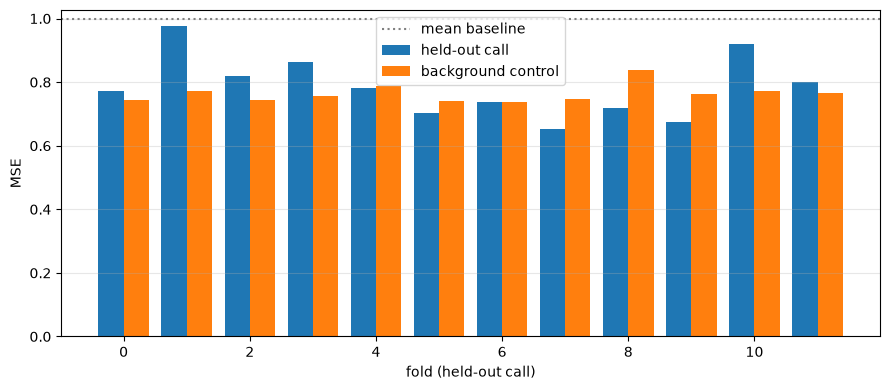

In [14]:
ms = np.array([r["mse"] for r in folds])
bs = np.array([r["bg"] for r in folds])

print("=========== RESULTS ===========")
print(f"chirp MSE      {ms.mean():.4f} +/- {ms.std():.4f}   "
      f"(variance explained {1 - ms.mean():.3f})")
print(f"background MSE {bs.mean():.4f} +/- {bs.std():.4f}")
print(f"ratio          {(bs / ms).mean():.2f}")
print()
if (bs / ms).mean() > 2:
    print("-> calls reconstruct much better than background: the model learned")
    print("   call structure, not the noise floor.")
else:
    print("-> background reconstructs about as well as calls: the model is")
    print("   memorizing clip noise. More data is the fix, not architecture.")

plt.figure(figsize=(9, 4))
xs = np.arange(N_CALLS)
plt.bar(xs - 0.2, ms, 0.4, label="held-out call")
plt.bar(xs + 0.2, bs, 0.4, label="background control")
plt.axhline(1.0, ls=":", c="gray", label="mean baseline")
plt.xlabel("fold (held-out call)"); plt.ylabel("MSE")
plt.legend(); plt.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 7. Look at the reconstructions

MSE will not tell you whether a reconstructed call is usable.

**What to read in the residual.** Unstructured speckle means the call was captured. A
**diagonal ridge** means the frequency range came out right but the sweep slope wrong — too
few latent dimensions to encode sweep rate. The whole call showing as a bright streak means
the model missed it and output something near the mean patch.

**Also watch the background texture** in the reconstruction row. A 4-dimensional code cannot
represent hundreds of independent noise values, so if the speckle is reproduced pixel for
pixel, that is memorization showing through.

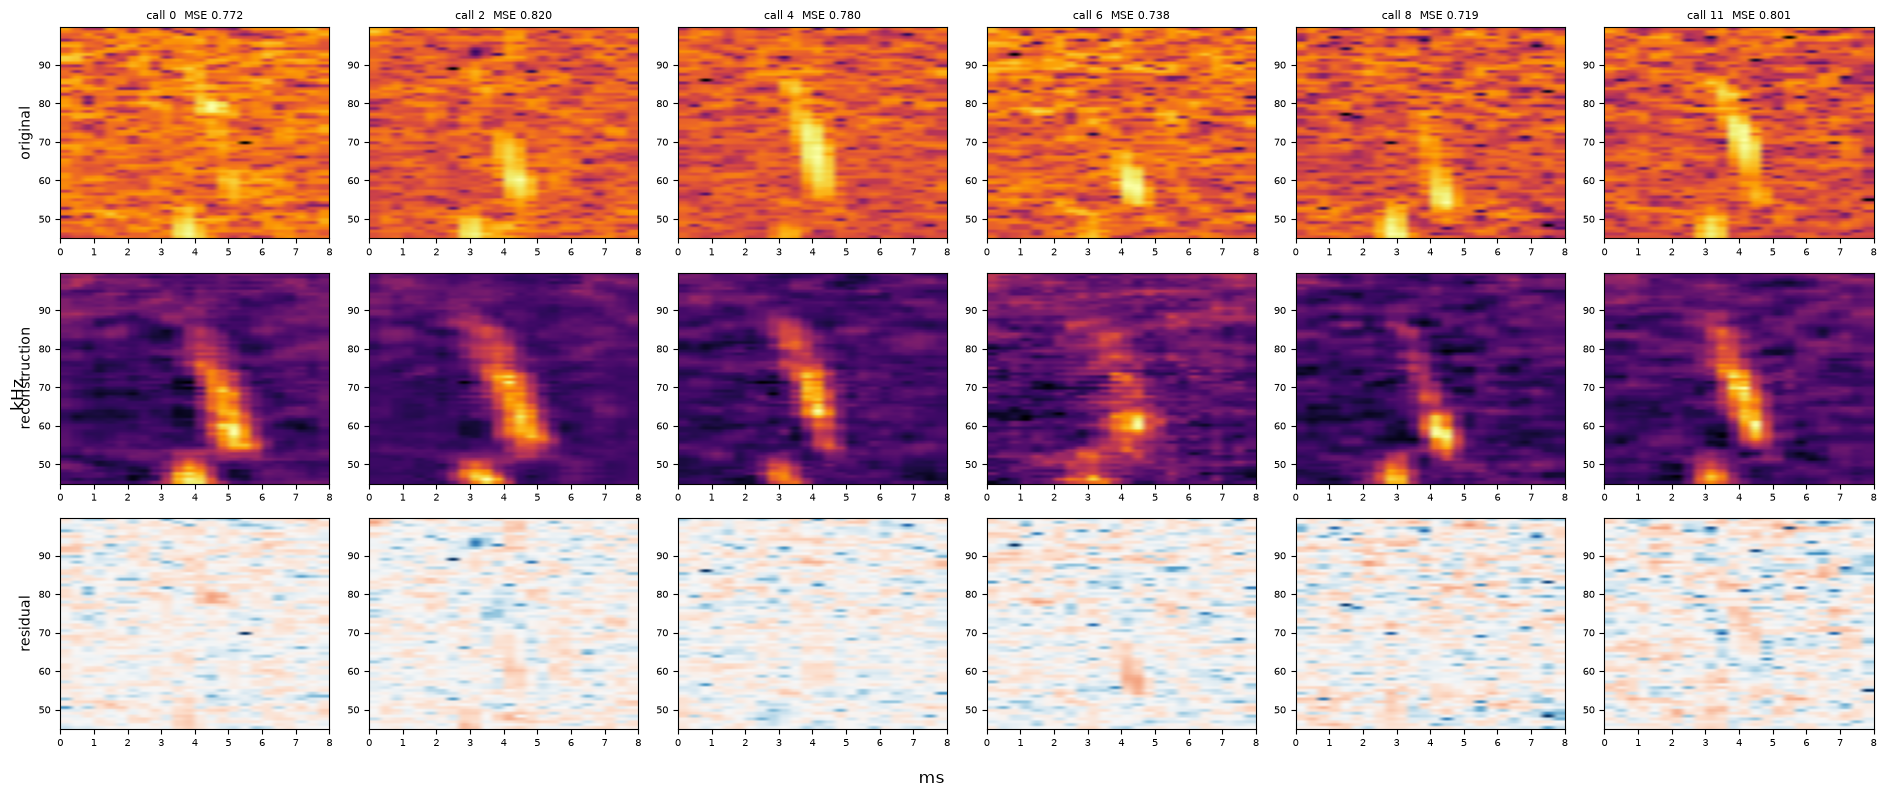

In [15]:
n_show = min(6, len(folds))
sel = np.linspace(0, len(folds) - 1, n_show).astype(int)

fig, axes = plt.subplots(3, n_show, figsize=(3.2 * n_show, 8), squeeze=False)
for j, fi in enumerate(sel):
    fd = folds[fi]
    m = fd["model"]; m.eval()
    with torch.no_grad():
        rec = m(torch.tensor(fd["va"]).to(device)).cpu().numpy()[0]
    orig = fd["va"][0]
    res = orig - rec

    for row, (data, cmap, lab) in enumerate([
        (orig, "inferno", "original"),
        (rec, "inferno", "reconstruction"),
        (res, "RdBu_r", "residual"),
    ]):
        a = axes[row][j]
        if cmap == "RdBu_r":
            v = np.abs(data).max()
            a.imshow(data.T, aspect="auto", origin="lower", cmap=cmap,
                     extent=ext, vmin=-v, vmax=v)
        else:
            a.imshow(data.T, aspect="auto", origin="lower", cmap=cmap, extent=ext)
        if j == 0:
            a.set_ylabel(lab)
        a.tick_params(labelsize=7)
    axes[0][j].set_title(f"call {fd['held']}  MSE {fd['mse']:.3f}", fontsize=8)

fig.supxlabel("ms"); fig.supylabel("kHz")
plt.tight_layout(); plt.show()

In [21]:
# =========================================================
# Call-region error, and a matching test
# =========================================================


recons, origs = [], []
for fd in folds:
    m = fd["model"]; m.eval()
    with torch.no_grad():
        r = m(torch.tensor(fd["va"]).to(device)).cpu().numpy()[0]
    recons.append(r); origs.append(fd["va"][0])
recons, origs = np.stack(recons), np.stack(origs)

# --- 1. split error by region -------------------------------------------
# call_e, bg_e = [], []
# for o, r in zip(origs, recons):
#     mask = o > o.mean() + 1.5 * o.std()          # the call pixels
#     call_e.append(float(((r - o) ** 2)[mask].mean()))
#     bg_e.append(float(((r - o) ** 2)[~mask].mean()))

# call_e, bg_e = np.array(call_e), np.array(bg_e)
# call_var = np.array([float(o[o > o.mean() + 1.5*o.std()].var()) for o in origs])

# print(f"call-pixel MSE       {call_e.mean():.3f}")
# print(f"call-pixel variance  {call_var.mean():.3f}")
# print(f"-> call variance explained: {1 - call_e.mean()/call_var.mean():.3f}")
# print(f"background-pixel MSE {bg_e.mean():.3f}")

call_e, bg_e, call_base = [], [], []
for o, r in zip(origs, recons):
    mask = o > o.mean() + 1.5 * o.std()
    call_e.append(float(((r - o) ** 2)[mask].mean()))
    bg_e.append(float(((r - o) ** 2)[~mask].mean()))
    call_base.append(float((o[mask] ** 2).mean()))     # cost of predicting 0

call_e, bg_e, call_base = map(np.array, (call_e, bg_e, call_base))
print(f"call-pixel MSE       {call_e.mean():.3f}")
print(f"baseline (predict 0) {call_base.mean():.3f}")
print(f"call variance explained: {1 - call_e.mean()/call_base.mean():.3f}")
print(f"background-pixel MSE {bg_e.mean():.3f}")

# --- 2. does recon_i match orig_i better than orig_j? -------------------
n = len(recons)
D = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        D[i, j] = float(np.mean((recons[i] - origs[j]) ** 2))

ranks = [int(np.where(np.argsort(D[i]) == i)[0][0]) for i in range(n)]
top1 = float(np.mean([r == 0 for r in ranks]))
print()
print(f"matching: top-1 accuracy {top1:.2f}  (chance {1/n:.2f})")
print(f"mean rank of correct match: {np.mean(ranks):.2f} of {n}")
print("ranks:", ranks)

call-pixel MSE       1.589
baseline (predict 0) 4.777
call variance explained: 0.667
background-pixel MSE 0.742

matching: top-1 accuracy 0.17  (chance 0.08)
mean rank of correct match: 3.50 of 12
ranks: [0, 9, 5, 6, 1, 1, 3, 0, 4, 1, 8, 4]


### Background controls, same model

These patches contain no call. If they come back looking like their originals, the model is
reproducing memorized noise.

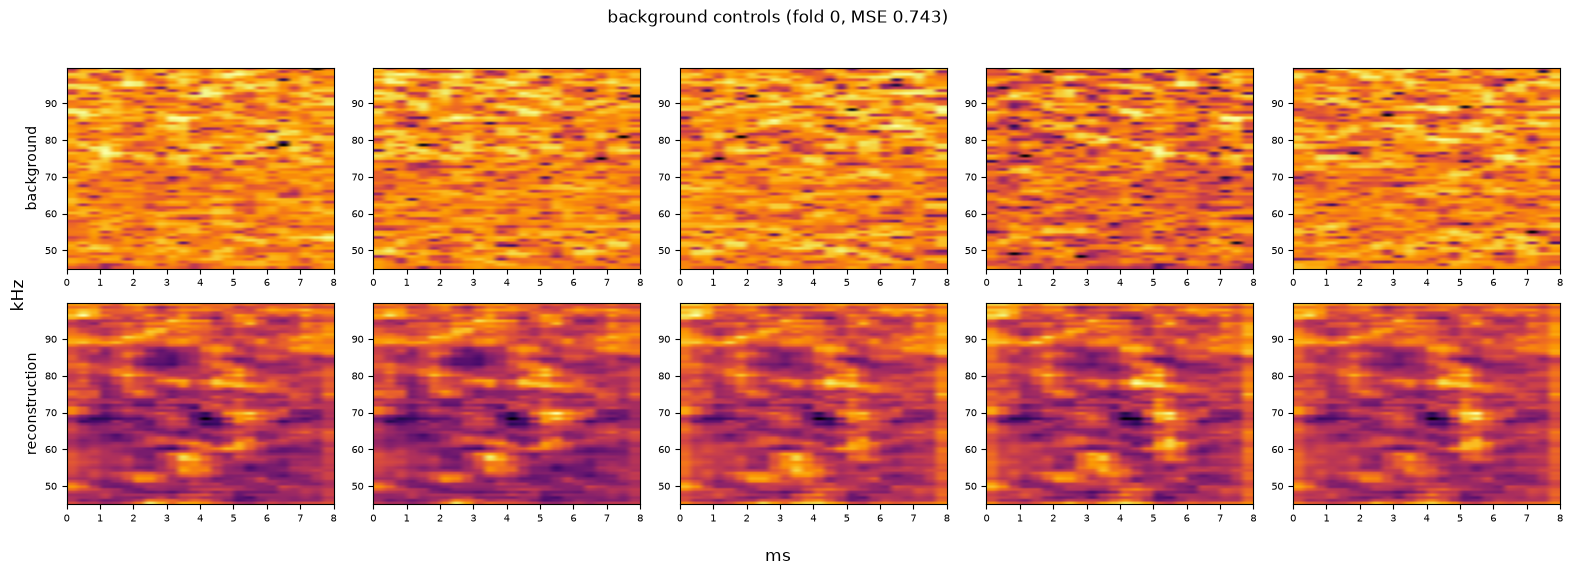

In [17]:
fd = folds[0]
m = fd["model"]; m.eval()
with torch.no_grad():
    rb = m(torch.tensor(fd["bg_s"]).to(device)).cpu().numpy()

n_show = min(5, len(rb))
fig, axes = plt.subplots(2, n_show, figsize=(3.2 * n_show, 5.5), squeeze=False)
for j in range(n_show):
    for row, (data, lab) in enumerate([(fd["bg_s"][j], "background"),
                                       (rb[j], "reconstruction")]):
        a = axes[row][j]
        a.imshow(data.T, aspect="auto", origin="lower", cmap="inferno", extent=ext)
        if j == 0:
            a.set_ylabel(lab)
        a.tick_params(labelsize=7)
fig.supxlabel("ms"); fig.supylabel("kHz")
plt.suptitle(f"background controls (fold 0, MSE {fd['bg']:.3f})", y=1.02)
plt.tight_layout(); plt.show()

## 8. PCA comparison

The linear baseline at the same bottleneck width. With this few examples PCA is close to
interpolating between the training calls, so a narrow win for the autoencoder is not strong
evidence of nonlinear structure.

The component images are the linear "call templates" the data supports.

In [18]:
pca_scores = []
for held in range(N_CALLS):
    tr_idx = [i for i in range(N_CALLS) if i != held]
    tr = calls[tr_idx].reshape(len(tr_idx), -1)
    va = calls[held:held + 1].reshape(1, -1)
    mu, sd = tr.mean(0, keepdims=True), tr.std(0, keepdims=True)
    sd[sd < 1e-8] = 1.0
    trs, vas = (tr - mu) / sd, (va - mu) / sd
    k = min(LATENT, len(tr_idx) - 1)
    p = PCA(n_components=k).fit(trs)
    pca_scores.append(float(np.mean((p.inverse_transform(p.transform(vas)) - vas) ** 2)))

pca_scores = np.array(pca_scores)
print(f"PCA-{LATENT}  {pca_scores.mean():.4f} +/- {pca_scores.std():.4f}")
print(f"conv AE  {ms.mean():.4f} +/- {ms.std():.4f}")
print(f"AE improvement: {(pca_scores.mean() - ms.mean()) / pca_scores.mean() * 100:+.1f}%")

PCA-4  1.7089 +/- 0.1805
conv AE  0.7851 +/- 0.0940
AE improvement: +54.1%


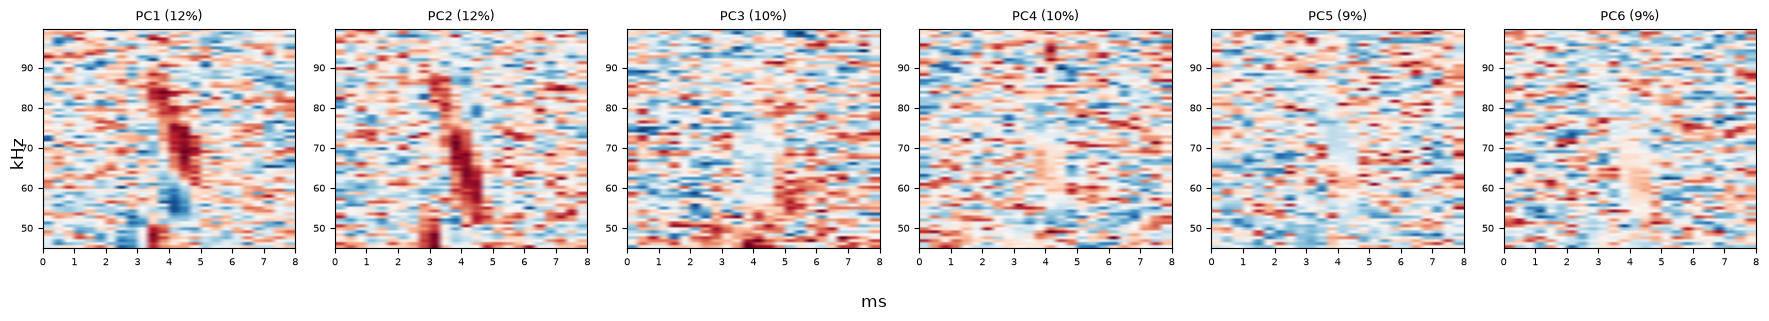

In [19]:
allf = calls.reshape(N_CALLS, -1)
mu_a, sd_a = allf.mean(0, keepdims=True), allf.std(0, keepdims=True)
sd_a[sd_a < 1e-8] = 1.0
p_all = PCA(n_components=min(6, N_CALLS - 1)).fit((allf - mu_a) / sd_a)

n_c = p_all.n_components_
fig, axes = plt.subplots(1, n_c, figsize=(3.0 * n_c, 3.2), squeeze=False)
for i in range(n_c):
    comp = p_all.components_[i].reshape(PATCH_T, N_BINS)
    v = np.abs(comp).max()
    a = axes[0][i]
    a.imshow(comp.T, aspect="auto", origin="lower", cmap="RdBu_r",
             extent=ext, vmin=-v, vmax=v)
    a.set_title(f"PC{i+1} ({p_all.explained_variance_ratio_[i]*100:.0f}%)", fontsize=9)
    a.tick_params(labelsize=7)
fig.supxlabel("ms"); fig.supylabel("kHz")
plt.tight_layout(); plt.show()

## 9. Latent sweep

A bat call has few real degrees of freedom — start frequency, end frequency, duration,
amplitude, curvature — so the elbow should be low. Full LOO at each width, so this is the
slowest cell in the notebook.

In [20]:
sweep = {}
for d in [2, 3, 4, 6, 8]:
    sc = []
    for held in range(N_CALLS):
        r = run_fold(held, lambda: TinyConvAE(PATCH_T, N_BINS, d),
                     epochs=200, patience=25)
        sc.append(r["mse"])
    sweep[d] = (float(np.mean(sc)), float(np.std(sc)))
    print(f"latent {d}: {sweep[d][0]:.4f} +/- {sweep[d][1]:.4f}")

ds = sorted(sweep)
means = [sweep[d][0] for d in ds]
stds = [sweep[d][1] for d in ds]

plt.figure(figsize=(9, 4))
plt.errorbar(ds, means, yerr=stds, fmt="o-", capsize=4, label="conv AE (LOO)")
plt.axhline(1.0, ls=":", c="gray", label="mean baseline")
plt.xlabel("latent dimension"); plt.ylabel("held-out MSE")
plt.legend(); plt.grid(alpha=0.3)
plt.title("look for the elbow, not the minimum")
plt.tight_layout(); plt.show()

latent 2: 0.8242 +/- 0.1219


KeyboardInterrupt: 

## Notes and next steps

**The binding constraint is data, not architecture.** Roughly ten calls from one bout of one
bat. Every result above is a pipeline demonstration. The single highest-value next step is
running this detector across the full 10-minute recording rather than the pre-cut clips —
the same threshold sweep in section 3 applies, and more bouts would make the leave-one-call-out
machinery unnecessary.

**If the background ratio is near 1**, do not tune the model. It means memorization, and only
more distinct calls will fix it.

**If the elbow in section 9 is at 3 or 4**, that is the interesting claim: a bat call in this
recording is describable by that many numbers. Verify it by regressing the latent dimensions
against measurable call properties — peak frequency, duration, bandwidth, sweep rate. Latents
that correlate with real acoustic parameters are far stronger evidence than any MSE.

**Watch for detector bias.** Thresholding on energy selects loud calls. Quiet or distant calls
are systematically absent, so the learned representation describes the loud subset.